# K-core group entity word clouds

Load one campaign's posts and account graph, find the highest-core author's exact core-shell component, and create combined entity word clouds.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from IPython.display import display
from wordcloud import WordCloud

## Parameters

In [2]:
campaign_name = "Ecuador"
topic_col = "BERTopic_topic_256"
top_percentage = 100

In [3]:
def parse_entity_list(value) -> list:
    """Convert a parquet entity value into a Python list.

    Args:
        value: List, JSON-list string, or another parquet value.

    Returns:
        Parsed entity list, or an empty list when unavailable.
    """
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        parsed_value = json.loads(value)
        return parsed_value if isinstance(parsed_value, list) else []
    if hasattr(value, "tolist"):
        parsed_value = value.tolist()
        return parsed_value if isinstance(parsed_value, list) else []
    return []


def find_project_root(start_path: str | Path) -> Path:
    """Find the project directory containing the results folder.

    Args:
        start_path: Directory from which to begin searching upward.

    Returns:
        Project directory containing ``results/Labeled_Datasets``.

    Raises:
        FileNotFoundError: If the project directory cannot be found.
    """
    start_path = Path(start_path).resolve()
    for candidate in (start_path, *start_path.parents):
        if (candidate / "results/Labeled_Datasets").is_dir():
            return candidate
    raise FileNotFoundError("Could not find the Backbone-Graph project root.")


project_root = find_project_root(Path.cwd())
dataset_part = f"{campaign_name}_part_all"
step_output_path = (
    project_root
    / "results/Labeled_Datasets"
    / campaign_name
    / dataset_part
    / "step_3_key_authors_graph"
    / f"topic_col_{topic_col}_top_percentage_{top_percentage:g}"
)
data_path = step_output_path / f"{dataset_part}_step_3.gzip.parquet"
graph_path = step_output_path / f"accounts_graph_topic_col_{topic_col}.gexf"
result_path = project_root / "result/k_core_group_wordclouds" / campaign_name

for required_path in (data_path, graph_path):
    if not required_path.exists():
        raise FileNotFoundError(f"Required input does not exist: {required_path}")

df = pd.read_parquet(
    data_path,
    columns=["accountid", "hashtags", "ner_entities"],
)
for entity_col in ("hashtags", "ner_entities"):
    df[entity_col] = df[entity_col].map(parse_entity_list)
G_accounts = nx.read_gexf(graph_path)

print(f"Campaign: {campaign_name}")
print(f"Posts: {len(df):,}")
print(
    f"Graph: {G_accounts.number_of_nodes():,} nodes, "
    f"{G_accounts.number_of_edges():,} edges"
)

Campaign: Ecuador
Posts: 1,469,036
Graph: 21,923 nodes, 610,106 edges


## Entity word-cloud function

In [4]:
def display_author_entities_wordcloud(
    df: pd.DataFrame,
    accountid: str | int | list[str | int],
    entity_cols: str | list[str],
    output_path: str | Path,
    author_col: str = "accountid",
    max_words: int = 200,
    width: int = 900,
    height: int = 450,
) -> pd.DataFrame:
    """Create a combined entity table and word cloud for accounts.

    Args:
        df: Posts DataFrame.
        accountid: One account ID or a list of account IDs to combine.
        entity_cols: Entity-list column or columns to count.
        output_path: Directory for the CSV and word-cloud image.
        author_col: Column containing account IDs.
        max_words: Maximum number of entities shown in the word cloud.
        width: Word-cloud width in pixels.
        height: Word-cloud height in pixels.

    Returns:
        Entity frequencies sorted from highest to lowest.
    """
    accountids = accountid if isinstance(accountid, list) else [accountid]
    accountids = list(dict.fromkeys(str(value) for value in accountids))
    entity_cols = [entity_cols] if isinstance(entity_cols, str) else entity_cols
    if not accountids:
        raise ValueError("accountid must contain at least one account ID.")

    author_rows = df.loc[
        df[author_col].astype(str).isin(accountids),
        entity_cols,
    ]
    entity_values = []
    for column in entity_cols:
        values = author_rows[column].explode().dropna().astype(str).str.strip()
        values = values[values.ne("")]
        if column == "hashtags":
            values = "#" + values.str.lstrip("#")
        entity_values.append(values)

    entities_df = (
        pd.concat(entity_values, ignore_index=True)
        .value_counts()
        .rename_axis("entity")
        .reset_index(name="count")
    )
    output_path = Path(output_path)
    output_path.mkdir(parents=True, exist_ok=True)
    entities_df.to_csv(output_path / "entities.csv", index=False)

    if entities_df.empty:
        print(f"No entities found for {len(accountids):,} accounts.")
        return entities_df

    frequencies = entities_df.set_index("entity")["count"].to_dict()
    wordcloud = WordCloud(
        width=width,
        height=height,
        max_words=max_words,
        background_color="white",
        collocations=False,
    ).generate_from_frequencies(frequencies)

    fig, ax = plt.subplots(figsize=(width / 100, height / 100))
    ax.imshow(wordcloud, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(
        f"Top {', '.join(entity_cols)} for {len(accountids):,} accounts",
        fontsize=16,
    )
    fig.tight_layout()
    fig.savefig(output_path / "wordcloud.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    display(entities_df.head(20))
    return entities_df

## Highest-core group

In [5]:
def get_top_core_group(G: nx.Graph) -> tuple[str, int, set[str]]:
    """Find the top-core author and its exact-shell component.

    Args:
        G: Undirected account graph.

    Returns:
        Top author ID, its core number, and other nodes in its connected
        component containing only nodes with that exact core number.
    """
    core_numbers = nx.core_number(G)
    highest_core = max(core_numbers.values())
    highest_core_nodes = [
        node for node, core_number in core_numbers.items()
        if core_number == highest_core
    ]
    top_core_user = min(
        highest_core_nodes,
        key=lambda node: (-G.degree(node), str(node)),
    )
    core_shell = G.subgraph(highest_core_nodes)
    component_nodes = set(
        nx.node_connected_component(core_shell, top_core_user)
    )
    component_nodes.discard(top_core_user)
    return str(top_core_user), highest_core, {str(node) for node in component_nodes}


top_core_user, top_core_number, top_core_user_k_core_nodes = (
    get_top_core_group(G_accounts)
)

group_summary_df = pd.DataFrame({
    "campaign": [campaign_name],
    "top_core_user": [top_core_user],
    "core_number": [top_core_number],
    "group_size_excluding_top_user": [len(top_core_user_k_core_nodes)],
})
result_path.mkdir(parents=True, exist_ok=True)
group_summary_df.to_csv(result_path / "group_summary.csv", index=False)
display(group_summary_df)

,campaign,top_core_user,core_number,group_size_excluding_top_user
0,Ecuador,0eff44692c4fc860d3d6eba9f2a6e0ba66a14224d9,277,321


## Group word clouds

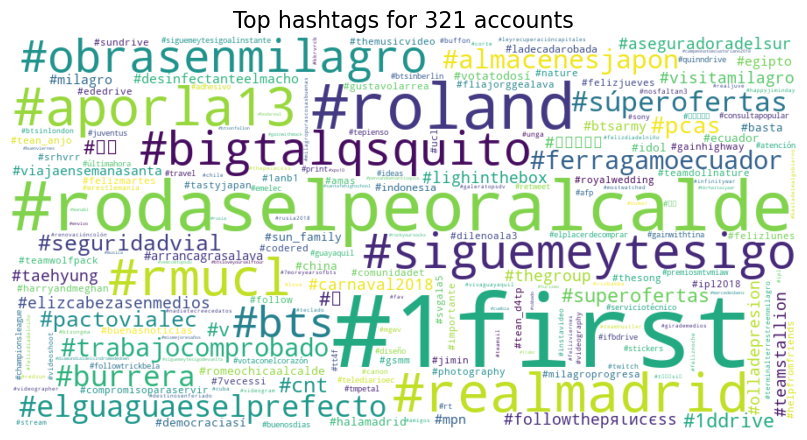

,entity,count
0,#1first,582
1,#rodaselpeoralcalde,564
2,#roland,467
3,#realmadrid,321
4,#aporla13,314
5,#rmucl,293
6,#siguemeytesigo,267
7,#bigtalqsquito,257
8,#obrasenmilagro,250
9,#bts,229


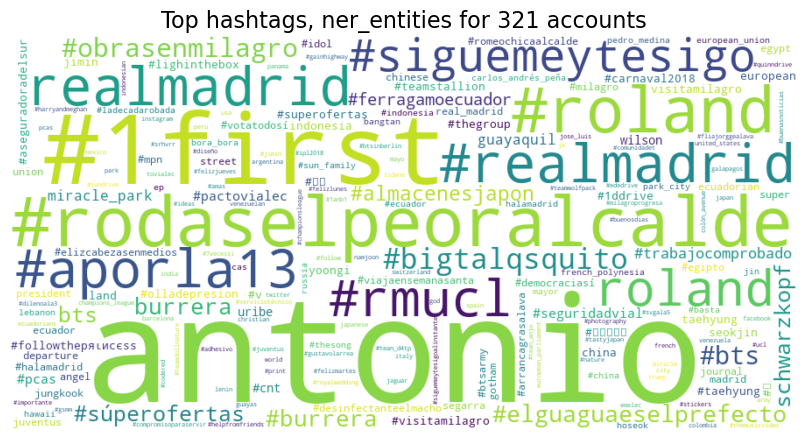

,entity,count
0,antonio,1845
1,#1first,582
2,#rodaselpeoralcalde,564
3,#roland,467
4,#realmadrid,321
5,realmadrid,317
6,#aporla13,314
7,#rmucl,293
8,roland,273
9,#siguemeytesigo,267


Saved results to: /home/amitner/Backbone-Graph/result/k_core_group_wordclouds/Ecuador


In [6]:
group_accountids = sorted(top_core_user_k_core_nodes)

hashtag_entities_df = display_author_entities_wordcloud(
    df=df,
    accountid=group_accountids,
    entity_cols=["hashtags"],
    output_path=result_path / "hashtags",
)

hashtag_ner_entities_df = display_author_entities_wordcloud(
    df=df,
    accountid=group_accountids,
    entity_cols=["hashtags", "ner_entities"],
    output_path=result_path / "hashtags_ner_entities",
)

print(f"Saved results to: {result_path}")